In [1]:
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END
from typing import TypedDict 

/home/pinaka-linux/langchain/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class SubState(TypedDict):
    input_text: str
    translated_text: str

In [3]:
sub_llm = ChatOllama(model="llama3")
def translate(state: SubState) -> SubState:
    response = sub_llm.invoke(f"Translate the following text to French: {state['input_text']}")
    return {"translated_text" : response.content}

sub = StateGraph(SubState)
sub.add_node("translate", translate)
sub.add_edge(START, "translate")
sub.add_edge("translate", END)
sub_graph = sub.compile()
sub_graph

In [4]:
class State(TypedDict):
    question: str
    english_answer: str
    french_answer: str
parent_llm = ChatOllama(model="llama3")
def answer_question(state: State) -> State:
    response = parent_llm.invoke(f"Answer the following question in English: {state['question']}")
    return {"english_answer" : response.content}

def translate_to_french(state: State) -> State:
    sub_state = {"input_text": state["english_answer"]}
    response = sub_llm.invoke(f"Translate the following text to French: {sub_state['input_text']}")
    return {"french_answer" : response.content}

graph = StateGraph(State)
graph.add_node("answer_question", answer_question)
graph.add_node("translate_to_french", translate_to_french)

graph.add_edge(START, "answer_question")
graph.add_edge("answer_question", "translate_to_french")
graph.add_edge("translate_to_french", END)
model = graph.compile()

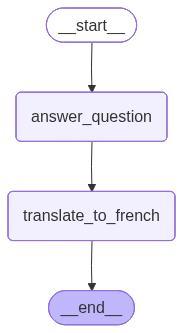

In [5]:
from IPython.display import Image
Image(model.get_graph().draw_mermaid_png())

In [6]:
question = "What is the capital of France?"
initial_state = {"question": question}
final_state = model.invoke(initial_state)
final_state

{'question': 'What is the capital of France?',
 'english_answer': 'The capital of France is Paris.',
 'french_answer': 'La capitale de la France est Paris.\n\nNote: This translation is straightforward, as "capital" and "Paris" are already translated in the original sentence. If you\'d like me to translate a different phrase or text, feel free to ask!'}